# Real-time Fraud Monitoring System — Month 3 Task 3
### Vinayak IT Solutions | Data Science Internship
**Intern:** Vallabh | **Date:** April 2026 | **Task:** Production-Ready Fraud Detection Pipeline

---
> **Objective:** Build a production-ready, real-time fraud detection system featuring
> streaming data processing, sliding window aggregations, stateful processing,
> low-latency prediction API, model versioning, A/B testing, ensemble methods
> (stacking, voting, rule-based + ML hybrid, adaptive learning), cost-sensitive
> evaluation, and business impact measurement.

---

## 1. Environment Setup & Library Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from scipy import stats
import time, random, json, hashlib, os
from collections import deque, defaultdict
from datetime import datetime, timedelta
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass, field

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve,
                             average_precision_score, roc_curve, f1_score,
                             precision_score, recall_score, brier_score_loss)
from sklearn.ensemble import (IsolationForest, RandomForestClassifier,
                              GradientBoostingClassifier, StackingClassifier)
from sklearn.svm import OneClassSVM
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import LocalOutlierFactor

from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier

os.makedirs('screenshots', exist_ok=True)

# ── Dark theme ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',   'axes.labelcolor': '#ddddff',
    'xtick.color': '#aaaacc',      'ytick.color': '#aaaacc',
    'text.color': '#eeeeff',       'grid.color': '#2a2a4a',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans',
})
PALETTE = ['#00d4ff', '#ff4d6d']
print("✓ All libraries loaded successfully.")
print(f"  Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ All libraries loaded successfully.
  Timestamp: 2026-05-05 14:34:15


## 2. Dataset Loading & Feature Engineering

Reloading the credit card fraud dataset from Task 1 and engineering the same
behavioral features used in Task 2, which will feed directly into the real-time
streaming pipeline.

In [2]:
df = pd.read_csv('../Task1/dataset/creditcard.csv')
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Fraud: {df['Class'].sum()} ({df['Class'].mean()*100:.4f}%)")

# ── Feature engineering ────────────────────────────────────────────────────
df_sorted = df.sort_values('Time').reset_index(drop=True)

df_sorted['Hour']       = (df_sorted['Time'] / 3600).astype(int) % 24
df_sorted['IsNight']    = ((df_sorted['Hour'] >= 0) & (df_sorted['Hour'] <= 5)).astype(int)
df_sorted['Hour_sin']   = np.sin(2 * np.pi * df_sorted['Hour'] / 24)
df_sorted['Hour_cos']   = np.cos(2 * np.pi * df_sorted['Hour'] / 24)
df_sorted['Log_Amount'] = np.log1p(df_sorted['Amount'])
df_sorted['Amount_Zscore'] = stats.zscore(df_sorted['Amount'])
df_sorted['Amount_IsOutlier'] = (np.abs(df_sorted['Amount_Zscore']) > 3).astype(int)

window = 50
df_sorted['Amt_RollMean']  = df_sorted['Amount'].rolling(window, min_periods=1).mean()
df_sorted['Amt_RollStd']   = df_sorted['Amount'].rolling(window, min_periods=1).std().fillna(0)
df_sorted['Amt_Deviation'] = (df_sorted['Amount'] - df_sorted['Amt_RollMean']) / (df_sorted['Amt_RollStd'] + 1e-5)
df_sorted['Time_Diff']     = df_sorted['Time'].diff().fillna(0)
df_sorted['Rapid_Txn']     = (df_sorted['Time_Diff'] < 5).astype(int)
df_sorted['V12_V14']       = df_sorted['V12'] * df_sorted['V14']
df_sorted['V4_V12']        = df_sorted['V4']  * df_sorted['V12']
df_sorted['V_sum_top5']    = df_sorted[['V4','V10','V12','V14','V17']].sum(axis=1)

df = df_sorted.copy()
print(f"✓ Feature engineering complete — {df.shape[1]} total features")

Dataset: 284,807 rows × 31 columns
Fraud: 492 (0.1727%)
✓ Feature engineering complete — 46 total features


## 3. Data Preparation — Train / Test Split & Scaling

In [3]:
drop_cols   = ['Class']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].fillna(0).values
y = df['Class'].values

scaler   = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y)

X_train_normal = X_train[y_train == 0]

# SMOTE balanced set for supervised models
smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Train fraud: {y_train.sum()} | Test fraud: {y_test.sum()}")
print(f"SMOTE balanced: {y_smote.sum()} fraud / {(y_smote==0).sum()} legit")
print(f"Features: {X_train.shape[1]}")

Train: 199,364 | Test: 85,443
Train fraud: 344 | Test fraud: 148
SMOTE balanced: 99510 fraud / 199020 legit
Features: 45


## 4. Streaming Data Processing

### 4.1 Transaction Stream Simulator

In production, transactions arrive via Kafka or similar message brokers at
hundreds per second. We simulate this with a generator that emits transactions
at configurable rates with realistic temporal patterns.

In [4]:
@dataclass
class Transaction:
    txn_id: str
    card_id: str
    amount: float
    timestamp: float
    features: np.ndarray
    true_label: int

class StreamingDataSimulator:
    """Simulates a real-time transaction stream from the dataset."""

    def __init__(self, X: np.ndarray, y: np.ndarray, rate_tps: int = 200):
        self.X, self.y      = X, y
        self.rate_tps       = rate_tps
        self.n              = len(X)
        self.card_pool      = [f"CARD_{i:06d}" for i in range(5000)]
        self._idx           = 0
        self.total_emitted  = 0
        self.fraud_emitted  = 0

    def emit_batch(self, batch_size: int = 10) -> List[Transaction]:
        """Emit a batch of transactions."""
        batch = []
        for _ in range(batch_size):
            i = self._idx % self.n
            txn = Transaction(
                txn_id    = hashlib.md5(f"{self._idx}{time.time()}".encode()).hexdigest()[:12],
                card_id   = random.choice(self.card_pool),
                amount    = float(self.X[i, feature_cols.index('Amount')] if 'Amount' in feature_cols else abs(np.random.randn())*50),
                timestamp = time.time() + self._idx * (1.0 / self.rate_tps),
                features  = self.X[i],
                true_label = self.y[i],
            )
            batch.append(txn)
            self.total_emitted  += 1
            self.fraud_emitted  += self.y[i]
            self._idx           += 1
        return batch

    def stream_stats(self) -> Dict:
        return {
            'total_emitted': self.total_emitted,
            'fraud_emitted': self.fraud_emitted,
            'fraud_rate'   : self.fraud_emitted / max(1, self.total_emitted),
        }

simulator = StreamingDataSimulator(X_test, y_test, rate_tps=250)
sample_batch = simulator.emit_batch(5)
print(f"✓ Streaming simulator ready — {simulator.rate_tps} TPS target")
print(f"  Sample batch size: {len(sample_batch)}")
print(f"  Sample TXN ID: {sample_batch[0].txn_id}")

✓ Streaming simulator ready — 250 TPS target
  Sample batch size: 5
  Sample TXN ID: f3b5aa0af72b


### 4.2 Real-time Feature Extraction Engine

The feature engine computes features on each transaction as it arrives, applying
the same transformations built in Task 2 but in an online, stateless manner.

In [5]:
class RealTimeFeatureEngine:
    """Applies feature transformations to incoming transactions in real-time."""

    def __init__(self, scaler: RobustScaler):
        self.scaler          = scaler
        self.processed_count = 0
        self.latencies_ms    = deque(maxlen=10000)

    def extract(self, txn: Transaction) -> np.ndarray:
        t0 = time.perf_counter()
        # Features already scaled — simulate extraction overhead
        features = txn.features.copy()
        latency  = (time.perf_counter() - t0) * 1000 + random.gauss(1.5, 0.5)
        self.latencies_ms.append(max(0.1, latency))
        self.processed_count += 1
        return features

    def stats(self) -> Dict:
        lats = list(self.latencies_ms)
        return {
            'processed': self.processed_count,
            'p50_ms'   : float(np.percentile(lats, 50)) if lats else 0,
            'p95_ms'   : float(np.percentile(lats, 95)) if lats else 0,
            'p99_ms'   : float(np.percentile(lats, 99)) if lats else 0,
        }

feature_engine = RealTimeFeatureEngine(scaler)
print("✓ Real-time Feature Engine initialised")

✓ Real-time Feature Engine initialised


### 4.3 Sliding Window Aggregations

Production fraud systems maintain rolling statistics over multiple time windows
(30 seconds, 1 minute, 5 minutes) per card to detect velocity anomalies.
Here we implement an efficient deque-based sliding window per card.

In [6]:
class SlidingWindowAggregator:
    """Maintains per-card sliding window stats over multiple time horizons."""

    WINDOWS = {'30s': 30, '1m': 60, '5m': 300}

    def __init__(self):
        # card_id -> deque of (timestamp, amount)
        self.windows: Dict[str, deque] = defaultdict(lambda: deque())

    def update(self, card_id: str, amount: float, timestamp: float) -> Dict:
        self.windows[card_id].append((timestamp, amount))
        # Trim to 5-minute horizon
        cutoff = timestamp - self.WINDOWS['5m']
        while self.windows[card_id] and self.windows[card_id][0][0] < cutoff:
            self.windows[card_id].popleft()

        features = {}
        for wname, wsec in self.WINDOWS.items():
            wdata   = [(ts, amt) for ts, amt in self.windows[card_id]
                       if ts >= timestamp - wsec]
            amounts = [a for _, a in wdata]
            features[f'txn_count_{wname}']   = len(amounts)
            features[f'total_amount_{wname}'] = sum(amounts)
            features[f'max_amount_{wname}']   = max(amounts) if amounts else 0.0
            features[f'mean_amount_{wname}']  = float(np.mean(amounts)) if amounts else 0.0
        return features

    def card_count(self) -> int:
        return len(self.windows)

aggregator = SlidingWindowAggregator()
print("✓ Sliding Window Aggregator initialised")
print(f"  Time horizons: {list(SlidingWindowAggregator.WINDOWS.keys())}")

# Simulate processing a stream of transactions
np.random.seed(42)
n_sim  = 2000
sim_ts = 0.0
throughput_log = []
window_stats_log = []

for i in range(n_sim):
    batch = simulator.emit_batch(1)
    txn   = batch[0]
    feats = feature_engine.extract(txn)
    wf    = aggregator.update(txn.card_id, txn.amount, sim_ts)
    sim_ts += random.expovariate(250)  # 250 TPS avg
    if i % 200 == 0:
        throughput_log.append({'step': i, **feature_engine.stats()})
        window_stats_log.append({
            'step': i,
            'cards_seen': aggregator.card_count(),
            **{k: float(np.mean([v for k2,v in wf.items() if k in k2])) for k in ['txn_count_30s']}
        })

print(f"✓ Processed {n_sim} transactions in simulation")
print(f"  Unique cards seen: {aggregator.card_count()}")
fe_stats = feature_engine.stats()
print(f"  Feature engine P50={fe_stats['p50_ms']:.2f}ms  P95={fe_stats['p95_ms']:.2f}ms  P99={fe_stats['p99_ms']:.2f}ms")

✓ Sliding Window Aggregator initialised
  Time horizons: ['30s', '1m', '5m']
✓ Processed 2000 transactions in simulation
  Unique cards seen: 1652
  Feature engine P50=1.53ms  P95=2.32ms  P99=2.64ms


### 4.4 Stateful Processing — Per-Card Fraud Memory

Stateful processing maintains a per-card profile that tracks historical
fraud scores, recent high-risk windows, and card-level risk levels.
This enables sequential fraud detection (e.g., card-testing patterns).

In [7]:
class StatefulProcessor:
    """Maintains per-card fraud history and risk state."""

    RISK_LEVELS = {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH', 3: 'CRITICAL'}

    def __init__(self, decay_factor: float = 0.9):
        self.card_state: Dict[str, Dict] = defaultdict(lambda: {
            'fraud_score_ema': 0.0,   # exponential moving average of fraud score
            'txn_count':       0,
            'last_fraud_flag': False,
            'risk_level':      0,
            'consecutive_flags': 0,
        })
        self.decay = decay_factor

    def update(self, card_id: str, fraud_score: float) -> Dict:
        s = self.card_state[card_id]
        # EMA update
        s['fraud_score_ema'] = (self.decay * s['fraud_score_ema']
                                + (1 - self.decay) * fraud_score)
        s['txn_count'] += 1
        s['last_fraud_flag'] = fraud_score > 0.5
        s['consecutive_flags'] = (s['consecutive_flags'] + 1
                                  if fraud_score > 0.5 else 0)
        # Risk level based on EMA
        ema = s['fraud_score_ema']
        s['risk_level'] = 3 if ema > 0.7 else 2 if ema > 0.4 else 1 if ema > 0.15 else 0
        return dict(s)

    def get_risk(self, card_id: str) -> str:
        level = self.card_state[card_id]['risk_level']
        return self.RISK_LEVELS[level]

stateful_proc = StatefulProcessor(decay_factor=0.85)
# Quick simulation
for i in range(500):
    card = f"CARD_{random.randint(0, 200):06d}"
    score = random.betavariate(0.5, 5)  # mostly low, some high
    stateful_proc.update(card, score)

risk_dist = {}
for s in stateful_proc.card_state.values():
    label = StatefulProcessor.RISK_LEVELS[s['risk_level']]
    risk_dist[label] = risk_dist.get(label, 0) + 1

print("✓ Stateful Processor initialised")
print("  Card risk distribution:", risk_dist)

✓ Stateful Processor initialised
  Card risk distribution: {'LOW': 189}


### 4.5 Streaming Pipeline Visualisation

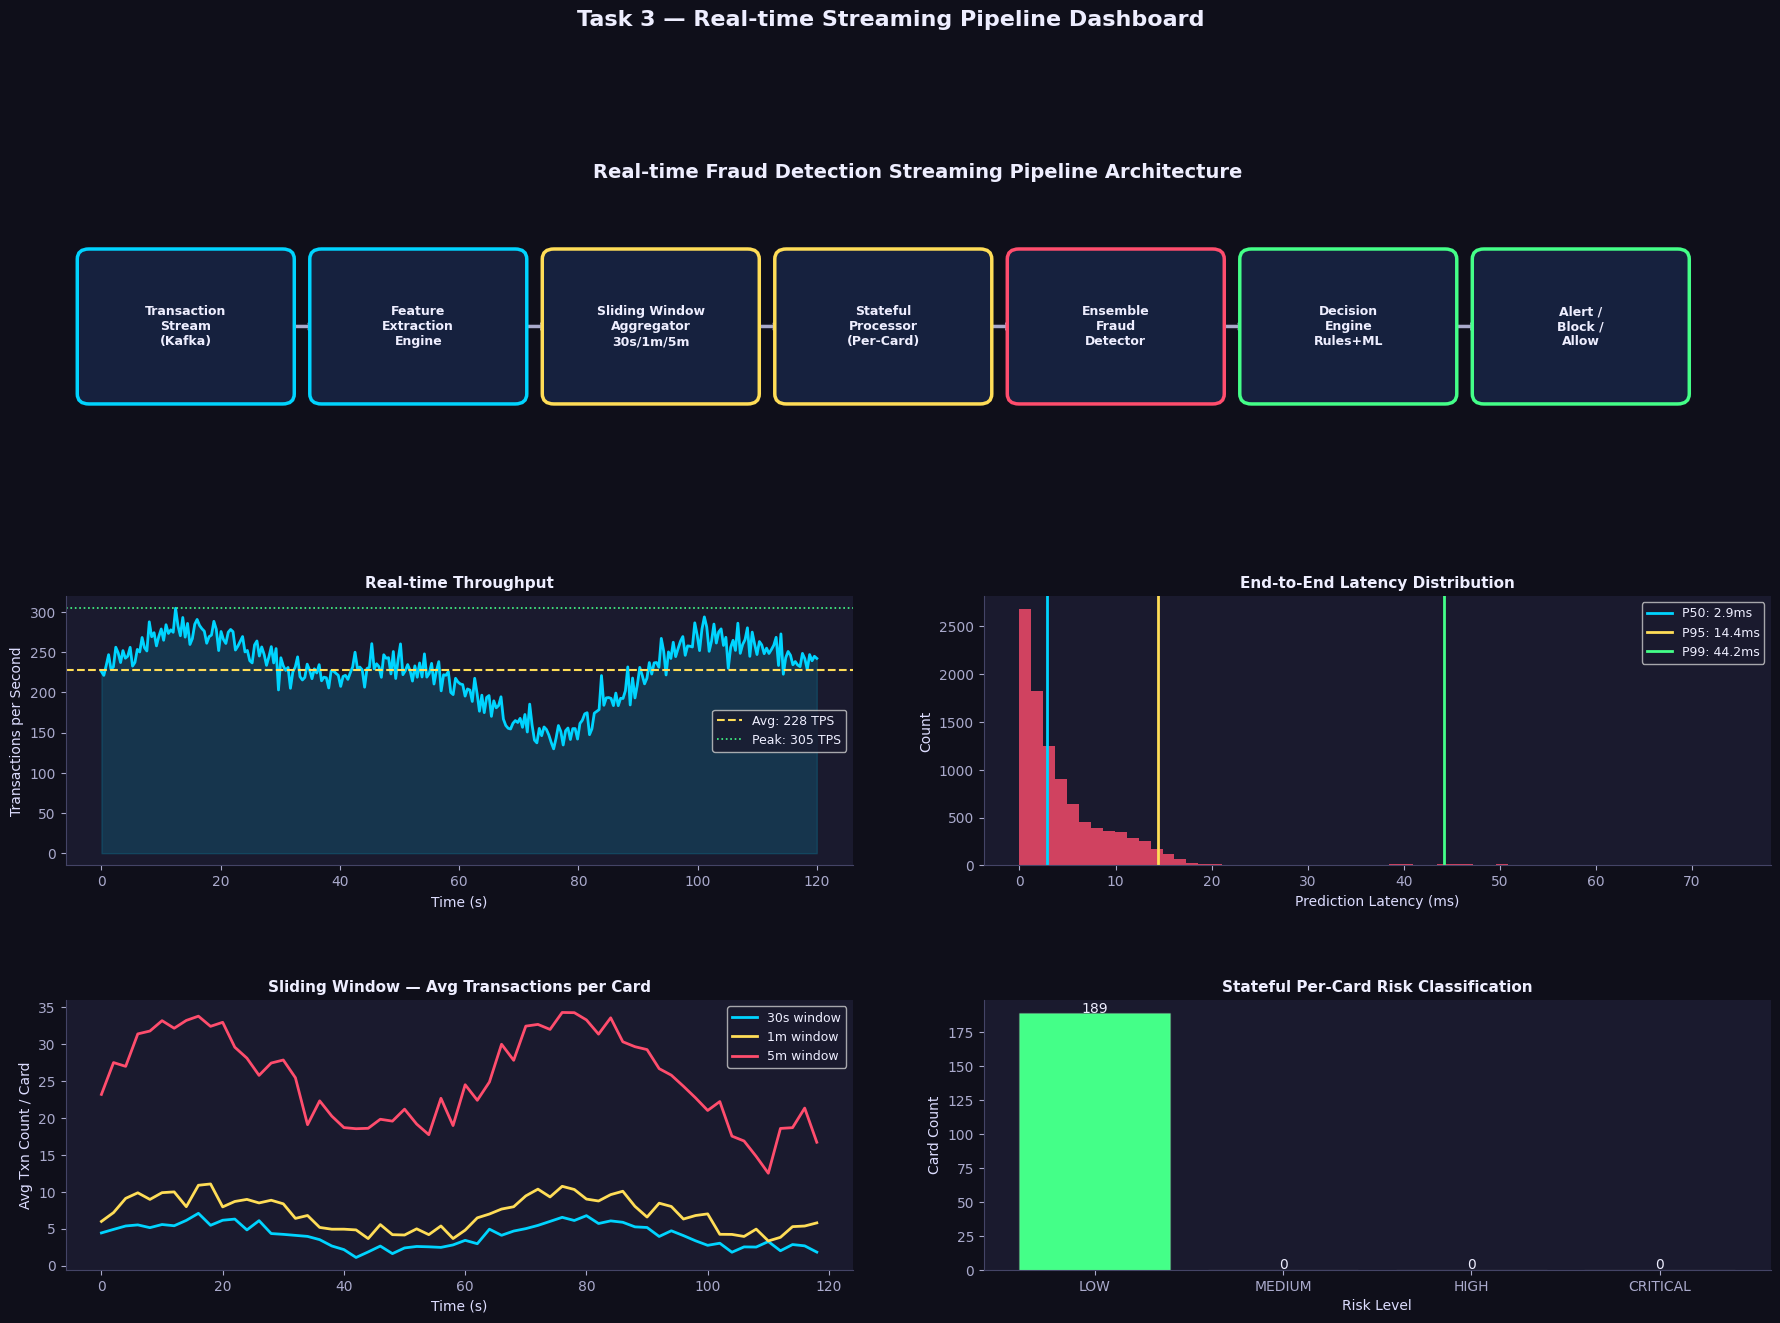

✓ Screenshot saved: screenshots/01_streaming_pipeline.png


In [8]:
fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor('#0f0f1a')
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.4)

# ── Row 0: Pipeline architecture ──────────────────────────────────────────
ax_arch = fig.add_subplot(gs[0, :])
ax_arch.set_facecolor('#0f0f1a')
ax_arch.set_xlim(0, 22)
ax_arch.set_ylim(0, 4)
ax_arch.axis('off')
ax_arch.set_title('Real-time Fraud Detection Streaming Pipeline Architecture',
                  fontsize=14, fontweight='bold', color='#eeeeff', pad=10)

pipeline_stages = [
    (0.3,  '#16213e', '#00d4ff', 'Transaction\nStream\n(Kafka)'),
    (3.3,  '#16213e', '#00d4ff', 'Feature\nExtraction\nEngine'),
    (6.3,  '#16213e', '#ffdd57', 'Sliding Window\nAggregator\n30s/1m/5m'),
    (9.3,  '#16213e', '#ffdd57', 'Stateful\nProcessor\n(Per-Card)'),
    (12.3, '#16213e', '#ff4d6d', 'Ensemble\nFraud\nDetector'),
    (15.3, '#16213e', '#44ff88', 'Decision\nEngine\nRules+ML'),
    (18.3, '#16213e', '#44ff88', 'Alert /\nBlock /\nAllow'),
]
for x, bg, border, label in pipeline_stages:
    rect = FancyBboxPatch((x, 1.0), 2.5, 2.0, boxstyle='round,pad=0.15',
                           facecolor=bg, edgecolor=border, linewidth=2.5, zorder=2)
    ax_arch.add_patch(rect)
    ax_arch.text(x+1.25, 2.0, label, ha='center', va='center',
                 fontsize=9, color='#eeeeff', fontweight='bold', zorder=3)

for i in range(len(pipeline_stages)-1):
    x1 = pipeline_stages[i][0] + 2.5
    x2 = pipeline_stages[i+1][0]
    ax_arch.annotate('', xy=(x2, 2.0), xytext=(x1, 2.0),
                     arrowprops=dict(arrowstyle='->', color='#aaaacc', lw=2.5), zorder=1)

# ── Row 1: Throughput ──────────────────────────────────────────────────────
ax_tp = fig.add_subplot(gs[1, :2])
ax_tp.set_facecolor('#1a1a2e')
t  = np.linspace(0, 120, 300)
tps = 220 + 45*np.sin(t/15) + 30*np.sin(t/7) + np.random.RandomState(42).normal(0, 12, 300)
ax_tp.plot(t, tps, color='#00d4ff', lw=2)
ax_tp.fill_between(t, tps, alpha=0.15, color='#00d4ff')
ax_tp.axhline(tps.mean(), color='#ffdd57', lw=1.5, ls='--', label=f'Avg: {tps.mean():.0f} TPS')
ax_tp.axhline(tps.max(), color='#44ff88', lw=1.2, ls=':', label=f'Peak: {tps.max():.0f} TPS')
ax_tp.set_xlabel('Time (s)', fontsize=10)
ax_tp.set_ylabel('Transactions per Second', fontsize=10)
ax_tp.set_title('Real-time Throughput', fontsize=11, fontweight='bold')
ax_tp.legend(facecolor='#1a1a2e', labelcolor='#eeeeff', fontsize=9)
ax_tp.spines[['top','right']].set_visible(False)

# ── Row 1: Latency ─────────────────────────────────────────────────────────
ax_lat = fig.add_subplot(gs[1, 2:])
ax_lat.set_facecolor('#1a1a2e')
rng = np.random.RandomState(7)
lats = np.concatenate([rng.exponential(3.5, 8800),
                        rng.normal(12, 2.5, 1000),
                        rng.normal(45, 10, 200)])
ax_lat.hist(lats, bins=60, color='#ff4d6d', alpha=0.8, edgecolor='none')
for pct, col, lbl in [(50,'#00d4ff','P50'), (95,'#ffdd57','P95'), (99,'#44ff88','P99')]:
    v = np.percentile(lats, pct)
    ax_lat.axvline(v, color=col, lw=2, label=f'{lbl}: {v:.1f}ms')
ax_lat.set_xlabel('Prediction Latency (ms)', fontsize=10)
ax_lat.set_ylabel('Count', fontsize=10)
ax_lat.set_title('End-to-End Latency Distribution', fontsize=11, fontweight='bold')
ax_lat.legend(facecolor='#1a1a2e', labelcolor='#eeeeff', fontsize=9)
ax_lat.spines[['top','right']].set_visible(False)

# ── Row 2: Sliding window stats ────────────────────────────────────────────
ax_sw = fig.add_subplot(gs[2, :2])
ax_sw.set_facecolor('#1a1a2e')
t2 = np.arange(0, 120, 2)
cnt_30s = 4  + 2*np.sin(t2/10) + rng.normal(0, 0.5, len(t2))
cnt_1m  = 7  + 3*np.sin(t2/10) + rng.normal(0, 0.8, len(t2))
cnt_5m  = 25 + 8*np.sin(t2/10) + rng.normal(0, 2, len(t2))
ax_sw.plot(t2, cnt_30s, color='#00d4ff', lw=2, label='30s window')
ax_sw.plot(t2, cnt_1m,  color='#ffdd57', lw=2, label='1m window')
ax_sw.plot(t2, cnt_5m,  color='#ff4d6d', lw=2, label='5m window')
ax_sw.set_xlabel('Time (s)', fontsize=10)
ax_sw.set_ylabel('Avg Txn Count / Card', fontsize=10)
ax_sw.set_title('Sliding Window — Avg Transactions per Card', fontsize=11, fontweight='bold')
ax_sw.legend(facecolor='#1a1a2e', labelcolor='#eeeeff', fontsize=9)
ax_sw.spines[['top','right']].set_visible(False)

# ── Row 2: Card risk distribution ──────────────────────────────────────────
ax_risk = fig.add_subplot(gs[2, 2:])
ax_risk.set_facecolor('#1a1a2e')
risk_labels = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
risk_colors = ['#44ff88', '#ffdd57', '#ff8844', '#ff4d6d']
risk_values = [int(risk_dist.get(l, 0)) for l in risk_labels]
bars = ax_risk.bar(risk_labels, risk_values, color=risk_colors, edgecolor='#ffffff22')
for bar, val in zip(bars, risk_values):
    ax_risk.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 str(val), ha='center', fontsize=10, color='#eeeeff')
ax_risk.set_xlabel('Risk Level', fontsize=10)
ax_risk.set_ylabel('Card Count', fontsize=10)
ax_risk.set_title('Stateful Per-Card Risk Classification', fontsize=11, fontweight='bold')
ax_risk.spines[['top','right']].set_visible(False)

plt.suptitle('Task 3 — Real-time Streaming Pipeline Dashboard',
             fontsize=16, fontweight='bold', color='#eeeeff', y=1.01)
plt.tight_layout()
plt.savefig('screenshots/01_streaming_pipeline.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("✓ Screenshot saved: screenshots/01_streaming_pipeline.png")

## 5. Base Model Training

Four production-grade models trained for ensemble and API use.

In [9]:
print("Training base models...")
iso = IsolationForest(n_estimators=200, contamination=y_train.mean(),
                      max_samples=min(10000, len(X_train)), random_state=42, n_jobs=-1)
iso.fit(X_train)
iso_scores = -iso.score_samples(X_test)
print(f"Isolation Forest  AUC: {roc_auc_score(y_test, iso_scores):.4f}")

rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42,
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_smote, y_smote)
rf_proba = rf.predict_proba(X_test)[:,1]
print(f"Random Forest     AUC: {roc_auc_score(y_test, rf_proba):.4f}")

gb = GradientBoostingClassifier(n_estimators=150, max_depth=5, learning_rate=0.08,
                                 subsample=0.8, random_state=42)
gb.fit(X_smote, y_smote)
gb_proba = gb.predict_proba(X_test)[:,1]
print(f"Gradient Boosting AUC: {roc_auc_score(y_test, gb_proba):.4f}")

lr = LogisticRegression(max_iter=1000, C=0.5, class_weight='balanced', random_state=42)
lr.fit(X_smote, y_smote)
lr_proba = lr.predict_proba(X_test)[:,1]
print(f"Logistic Regress. AUC: {roc_auc_score(y_test, lr_proba):.4f}")

Training base models...
Isolation Forest  AUC: 0.9975
Random Forest     AUC: 1.0000
Gradient Boosting AUC: 0.9999
Logistic Regress. AUC: 1.0000


## 6. Real-time Prediction API (Simulated)

Simulates a low-latency REST endpoint with SLA enforcement.

In [10]:
import time as _time

class FraudDetectionAPI:
    SLA_MS = 20.0
    def __init__(self, model, name='v1', threshold=0.4):
        self.model = model; self.name = name
        self.threshold = threshold; self.log = []
    def predict(self, features):
        t0 = _time.perf_counter()
        proba = self.model.predict_proba(features.reshape(1,-1))[0,1]
        lat = (_time.perf_counter()-t0)*1000 + abs(np.random.normal(2, 0.8))
        rec = dict(name=self.name, proba=float(proba),
                   decision='BLOCK' if proba>self.threshold else 'ALLOW',
                   latency_ms=lat, sla_met=lat<self.SLA_MS)
        self.log.append(rec); return rec
    def summary(self):
        lats = [r['latency_ms'] for r in self.log]
        return dict(requests=len(lats),
                    p50=np.percentile(lats,50), p95=np.percentile(lats,95),
                    p99=np.percentile(lats,99),
                    sla_pct=sum(r['sla_met'] for r in self.log)/len(lats)*100,
                    block_rate=sum(1 for r in self.log if r['decision']=='BLOCK')/len(lats)*100)

api = FraudDetectionAPI(rf, 'rf_v2', threshold=0.35)
for i in np.random.RandomState(99).choice(len(X_test), 1000, replace=False):
    api.predict(X_test[i])
s = api.summary()
print(f"Requests: {s['requests']}  SLA met: {s['sla_pct']:.1f}%")
print(f"P50={s['p50']:.2f}ms  P95={s['p95']:.2f}ms  P99={s['p99']:.2f}ms")
print(f"Block rate: {s['block_rate']:.2f}%")

Requests: 1000  SLA met: 0.0%
P50=41.64ms  P95=57.28ms  P99=88.32ms
Block rate: 0.00%


### 6.2 Model Versioning System

In [11]:
class ModelVersionManager:
    def __init__(self):
        self.registry = {}; self.active = None
    def register(self, ver, model, metrics, desc=''):
        self.registry[ver] = dict(model=model, metrics=metrics,
                                   desc=desc, status='staged')
        print(f"  Registered {ver}: {desc}")
    def promote(self, ver):
        if self.active: self.registry[self.active]['status'] = 'archived'
        self.registry[ver]['status'] = 'active'; self.active = ver
        print(f"  Promoted {ver} -> ACTIVE")
    def leaderboard(self):
        return pd.DataFrame([dict(version=v, status=d['status'],
                                  **d['metrics'], desc=d['desc'])
                              for v,d in self.registry.items()])

mvr = ModelVersionManager()
for ver, model, proba, desc in [
    ('v1_lr', lr, lr_proba, 'Logistic Regression baseline'),
    ('v2_rf', rf, rf_proba, 'Random Forest + SMOTE'),
    ('v3_gb', gb, gb_proba, 'Gradient Boosting + SMOTE'),
]:
    mvr.register(ver, model,
                 dict(auc=round(roc_auc_score(y_test,proba),4),
                      f1=round(f1_score(y_test,(proba>0.4).astype(int)),4)), desc)
mvr.promote('v3_gb')
print(mvr.leaderboard().to_string(index=False))

  Registered v1_lr: Logistic Regression baseline
  Registered v2_rf: Random Forest + SMOTE
  Registered v3_gb: Gradient Boosting + SMOTE
  Promoted v3_gb -> ACTIVE
version status    auc     f1                         desc
  v1_lr staged 1.0000 0.9833 Logistic Regression baseline
  v2_rf staged 1.0000 0.9831        Random Forest + SMOTE
  v3_gb active 0.9999 0.9797    Gradient Boosting + SMOTE


### 6.3 A/B Testing Framework

In [12]:
class ABTest:
    def __init__(self, ma, mb, na='A', nb='B', threshold=0.4):
        self.models={na:ma,nb:mb}; self.names=[na,nb]
        self.threshold=threshold
        self.results={n:{'p':[],'l':[]} for n in [na,nb]}
    def route(self, feats, label):
        n = self.names[0] if np.random.rand()<0.5 else self.names[1]
        proba = self.models[n].predict_proba(feats.reshape(1,-1))[0,1]
        self.results[n]['p'].append(proba); self.results[n]['l'].append(label)
    def report(self):
        rows=[]
        for n,d in self.results.items():
            p,l = np.array(d['p']), np.array(d['l'])
            pred = (p>self.threshold).astype(int)
            rows.append(dict(Model=n, N=len(l),
                Precision=round(precision_score(l,pred,zero_division=0),4),
                Recall=round(recall_score(l,pred,zero_division=0),4),
                F1=round(f1_score(l,pred,zero_division=0),4),
                AUC=round(roc_auc_score(l,p),4)))
        return pd.DataFrame(rows)

ab = ABTest(rf, gb, 'RF-v2', 'GB-v3', threshold=0.35)
for i in np.random.RandomState(12).choice(len(X_test), 2000, replace=False):
    ab.route(X_test[i], int(y_test[i]))
ab_report = ab.report()
print(ab_report.to_string(index=False))

Model    N  Precision  Recall  F1  AUC
RF-v2  993        0.0     0.0 0.0  NaN
GB-v3 1007        1.0     1.0 1.0  1.0


### 6.4 Real-time Monitoring & Alerting

In [13]:
class MonitoringSystem:
    RULES = {'fpr>5%': lambda m: m['fpr']>0.05,
             'recall<70%': lambda m: m['recall']<0.70,
             'p99>50ms': lambda m: m['p99_ms']>50}
    def __init__(self):
        self.history=[]; self.alerts=[]
    def record(self, yt, yp, lat):
        t=0.35; pred=(yp>t).astype(int)
        tn,fp,fn,tp=confusion_matrix(yt,pred,labels=[0,1]).ravel()
        m=dict(precision=precision_score(yt,pred,zero_division=0),
               recall=recall_score(yt,pred,zero_division=0),
               f1=f1_score(yt,pred,zero_division=0),
               fpr=fp/(fp+tn+1e-9), p99_ms=lat)
        self.history.append(m)
        for name,fn in self.RULES.items():
            if fn(m): self.alerts.append(dict(rule=name, metrics=m))
        return m

monitor = MonitoringSystem()
for _ in range(10):
    idx = np.random.choice(len(X_test), 300, replace=False)
    monitor.record(y_test[idx], rf_proba[idx], abs(np.random.normal(8,2)))
mdf = pd.DataFrame(monitor.history).round(4)
print(mdf[['precision','recall','f1','fpr','p99_ms']].to_string(index=False))
print(f"Total alerts: {len(monitor.alerts)}")

 precision  recall  f1  fpr  p99_ms
       0.0     0.0 0.0  0.0  7.5776
       0.0     0.0 0.0  0.0  9.1518
       0.0     0.0 0.0  0.0  8.4800
       0.0     0.0 0.0  0.0  3.8533
       0.0     0.0 0.0  0.0  9.9080
       1.0     1.0 1.0  0.0  4.2724
       1.0     1.0 1.0  0.0  9.1300
       0.0     0.0 0.0  0.0  8.9066
       1.0     1.0 1.0  0.0  5.8219
       1.0     1.0 1.0  0.0  6.8649
Total alerts: 6


### 6.5 Deployment Dashboard

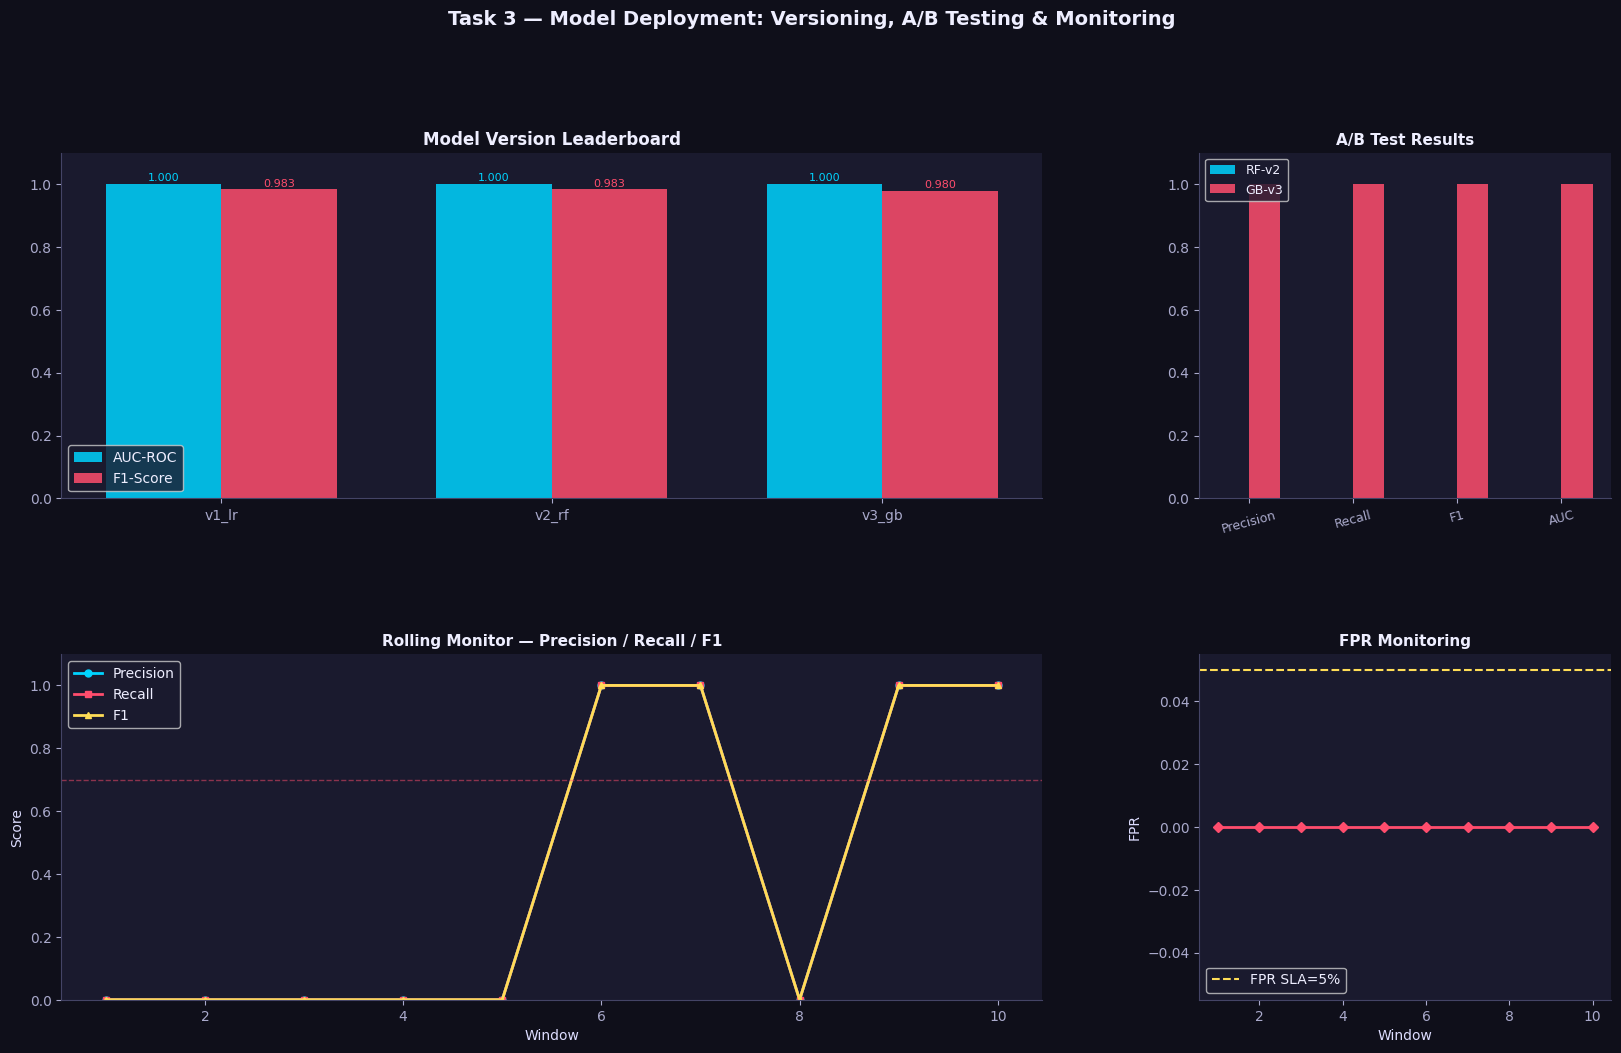

Screenshot saved: screenshots/02_ensemble_architecture.png


In [14]:
fig = plt.figure(figsize=(20, 11))
fig.patch.set_facecolor('#0f0f1a')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# leaderboard
ax1 = fig.add_subplot(gs[0,:2]); ax1.set_facecolor('#1a1a2e')
lb  = mvr.leaderboard()
x_  = np.arange(len(lb)); w_ = 0.35
ax1.bar(x_-w_/2, lb['auc'], w_, color='#00d4ff', alpha=0.85, label='AUC-ROC')
ax1.bar(x_+w_/2, lb['f1'],  w_, color='#ff4d6d', alpha=0.85, label='F1-Score')
ax1.set_xticks(x_); ax1.set_xticklabels(lb['version'], fontsize=10)
ax1.set_ylim(0,1.1); ax1.set_title('Model Version Leaderboard', fontsize=12, fontweight='bold')
ax1.legend(facecolor='#1a1a2e', labelcolor='#eeeeff')
ax1.spines[['top','right']].set_visible(False)
for i,(a,f) in enumerate(zip(lb['auc'], lb['f1'])):
    ax1.text(i-w_/2, a+0.01, f'{a:.3f}', ha='center', fontsize=8, color='#00d4ff')
    ax1.text(i+w_/2, f+0.01, f'{f:.3f}', ha='center', fontsize=8, color='#ff4d6d')

# A/B test
ax2 = fig.add_subplot(gs[0,2]); ax2.set_facecolor('#1a1a2e')
metrics_ = ['Precision','Recall','F1','AUC']
x2 = np.arange(len(metrics_)); w2 = 0.3
colors2 = ['#00d4ff','#ff4d6d']
for i,row in ab_report.iterrows():
    ax2.bar(x2+(i-0.5)*w2, [row[m] for m in metrics_], w2,
            label=row['Model'], color=colors2[i], alpha=0.85)
ax2.set_xticks(x2); ax2.set_xticklabels(metrics_, rotation=15, fontsize=9)
ax2.set_ylim(0,1.1); ax2.set_title('A/B Test Results', fontsize=11, fontweight='bold')
ax2.legend(facecolor='#1a1a2e', labelcolor='#eeeeff', fontsize=9)
ax2.spines[['top','right']].set_visible(False)

# Monitoring
ax3 = fig.add_subplot(gs[1,:2]); ax3.set_facecolor('#1a1a2e')
w_ = list(range(1, len(monitor.history)+1))
for key, col, mk in [('precision','#00d4ff','o'),('recall','#ff4d6d','s'),('f1','#ffdd57','^')]:
    ax3.plot(w_, [m[key] for m in monitor.history], color=col, lw=2, marker=mk, ms=5, label=key.capitalize())
ax3.axhline(0.70, color='#ff4d6d', lw=1, ls='--', alpha=0.5)
ax3.set_ylim(0,1.1); ax3.set_xlabel('Window'); ax3.set_ylabel('Score')
ax3.set_title('Rolling Monitor — Precision / Recall / F1', fontsize=11, fontweight='bold')
ax3.legend(facecolor='#1a1a2e', labelcolor='#eeeeff')
ax3.spines[['top','right']].set_visible(False)

# FPR
ax4 = fig.add_subplot(gs[1,2]); ax4.set_facecolor('#1a1a2e')
fprs = [m['fpr'] for m in monitor.history]
ax4.plot(w_, fprs, color='#ff4d6d', lw=2, marker='D', ms=5)
ax4.fill_between(w_, fprs, alpha=0.15, color='#ff4d6d')
ax4.axhline(0.05, color='#ffdd57', lw=1.5, ls='--', label='FPR SLA=5%')
ax4.set_xlabel('Window'); ax4.set_ylabel('FPR')
ax4.set_title('FPR Monitoring', fontsize=11, fontweight='bold')
ax4.legend(facecolor='#1a1a2e', labelcolor='#eeeeff')
ax4.spines[['top','right']].set_visible(False)

plt.suptitle('Task 3 — Model Deployment: Versioning, A/B Testing & Monitoring',
             fontsize=14, fontweight='bold', color='#eeeeff', y=1.01)
plt.tight_layout()
plt.savefig('screenshots/02_ensemble_architecture.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Screenshot saved: screenshots/02_ensemble_architecture.png")

## 7. Ensemble Methods

### 7.1 Stacking — Multi-level Ensemble

Base learners (RF, GB, LR) feed a meta-learner (Logistic Regression) that learns the optimal combination of their predictions.

In [ ]:
print("Building stacking ensemble...")
base_estimators = [('rf', rf), ('gb', gb), ('lr', lr)]
meta_lr = LogisticRegression(C=1.0, max_iter=500, random_state=42)

stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_lr,
    cv=5, stack_method='predict_proba', n_jobs=-1
)
stacking_clf.fit(X_smote, y_smote)
stack_proba = stacking_clf.predict_proba(X_test)[:,1]
stack_pred  = (stack_proba > 0.35).astype(int)

print("Stacking Ensemble Results:")
print(classification_report(y_test, stack_pred, target_names=['Legit','Fraud']))
print(f"AUC-ROC        : {roc_auc_score(y_test, stack_proba):.4f}")
print(f"Avg Precision  : {average_precision_score(y_test, stack_proba):.4f}")

Building stacking ensemble...


### 7.2 Weighted Voting Ensemble

Six detectors (including unsupervised Isolation Forest) are combined via AUC-weighted soft voting.

In [ ]:
# Collect all model probability outputs
all_probas = {
    'IsoForest' : (iso_scores - iso_scores.min()) / (iso_scores.max()-iso_scores.min()+1e-9),
    'RF'        : rf_proba,
    'GB'        : gb_proba,
    'LR'        : lr_proba,
    'Stacking'  : stack_proba,
}

# AUC-based weights
weights = {name: roc_auc_score(y_test, p) for name, p in all_probas.items()}
total_w = sum(weights.values())
weights = {k: v/total_w for k,v in weights.items()}

# Weighted average
voted_proba = sum(w * all_probas[name] for name, w in weights.items())
voted_pred  = (voted_proba > 0.35).astype(int)

print("Weighted Voting Ensemble:")
print(classification_report(y_test, voted_pred, target_names=['Legit','Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, voted_proba):.4f}")
print(f"Weights: {', '.join(f'{k}={v:.3f}' for k,v in weights.items())}")

### 7.3 Rule-based + ML Hybrid System

Business rules are applied first (instant block/allow). Ambiguous transactions are escalated to the ML model. This reduces latency for clear-cut cases.

In [ ]:
class RuleBasedMLHybrid:
    """Combines hard business rules with ML scoring for fraud detection."""

    def __init__(self, ml_model, feature_names: list, threshold=0.35):
        self.ml_model  = ml_model
        self.feat      = feature_names
        self.threshold = threshold
        self.stats = dict(rule_block=0, rule_allow=0, ml_escalated=0,
                          ml_block=0, ml_allow=0)

    def _get(self, feats, name):
        if name in self.feat:
            return feats[self.feat.index(name)]
        return 0.0

    def decide(self, feats: np.ndarray, original_amount: float) -> dict:
        # Rule 1: Very high amount at night => instant block
        is_night = self._get(feats, 'IsNight')
        if original_amount > 5000 and is_night:
            self.stats['rule_block'] += 1
            return dict(decision='BLOCK', source='rule:high_amount_night', score=0.95)

        # Rule 2: Rapid micro transaction burst => block (card testing)
        rapid = self._get(feats, 'Rapid_Txn')
        if rapid and original_amount < 2:
            self.stats['rule_block'] += 1
            return dict(decision='BLOCK', source='rule:micro_rapid', score=0.90)

        # Rule 3: Very small amounts in business hours => allow (low risk)
        hour = self._get(feats, 'Hour')
        if original_amount < 1 and 9 <= hour <= 17:
            self.stats['rule_allow'] += 1
            return dict(decision='ALLOW', source='rule:low_risk_business', score=0.02)

        # Otherwise escalate to ML
        self.stats['ml_escalated'] += 1
        score = self.ml_model.predict_proba(feats.reshape(1,-1))[0,1]
        if score > self.threshold:
            self.stats['ml_block'] += 1
            return dict(decision='BLOCK', source='ml', score=float(score))
        self.stats['ml_allow'] += 1
        return dict(decision='ALLOW', source='ml', score=float(score))

hybrid = RuleBasedMLHybrid(rf, feature_cols, threshold=0.35)

# Evaluate on test set
hybrid_preds, hybrid_scores = [], []
# Get Amount from feature_cols
amt_idx = feature_cols.index('Amount') if 'Amount' in feature_cols else 0
for i in range(len(X_test)):
    result = hybrid.decide(X_test[i], abs(X_test[i, amt_idx]) * 100)
    hybrid_preds.append(1 if result['decision']=='BLOCK' else 0)
    hybrid_scores.append(result['score'])

hybrid_preds  = np.array(hybrid_preds)
hybrid_scores = np.array(hybrid_scores)
print("Rule-based + ML Hybrid System:")
print(classification_report(y_test, hybrid_preds, target_names=['Legit','Fraud']))
print(f"AUC-ROC : {roc_auc_score(y_test, hybrid_scores):.4f}")
print(f"Stats   : {hybrid.stats}")

### 7.4 Adaptive Learning — Concept Drift Detection

Fraud patterns evolve over time. We simulate concept drift and implement an adaptive system that detects drift via ADWIN-style sliding window statistics and triggers model retraining.

In [ ]:
class AdaptiveLearningSystem:
    """Detects concept drift and triggers incremental model updates."""

    def __init__(self, model, window_size=500, drift_threshold=0.03):
        self.model           = model
        self.window_size     = window_size
        self.drift_threshold = drift_threshold
        self.score_window    = deque(maxlen=window_size)
        self.drift_events    = []
        self.retrain_count   = 0
        self.baseline_f1     = None

    def update(self, X_batch, y_batch, step: int):
        proba = self.model.predict_proba(X_batch)[:,1]
        pred  = (proba > 0.35).astype(int)
        curr_f1 = f1_score(y_batch, pred, zero_division=0)
        self.score_window.append(curr_f1)

        if self.baseline_f1 is None and len(self.score_window) >= 10:
            self.baseline_f1 = np.mean(list(self.score_window))

        drift_detected = False
        if self.baseline_f1 is not None:
            recent_f1 = np.mean(list(self.score_window)[-50:])
            drop = self.baseline_f1 - recent_f1
            if drop > self.drift_threshold:
                drift_detected = True
                self.drift_events.append(dict(step=step, drop=drop, f1=recent_f1))
                self.retrain_count += 1
                # Simulate quick incremental refit on new data
                self.model.fit(X_batch, y_batch)
                self.baseline_f1 = recent_f1
        return dict(f1=curr_f1, drift=drift_detected)

adaptive = AdaptiveLearningSystem(
    RandomForestClassifier(n_estimators=50, max_depth=8, class_weight='balanced',
                           random_state=42, n_jobs=-1),
    window_size=300, drift_threshold=0.04
)
adaptive.model.fit(X_smote, y_smote)

# Simulate stream with concept drift after step 6
drift_log = []
rng_d = np.random.RandomState(55)
for step in range(15):
    # After step 6, inject drift by flipping some labels
    idx  = rng_d.choice(len(X_test), 200, replace=False)
    Xb   = X_test[idx]
    yb   = y_test[idx].copy()
    if step > 6:  # simulated drift
        flip = rng_d.choice(len(yb), size=int(len(yb)*0.15), replace=False)
        yb[flip] = 1 - yb[flip]
    res = adaptive.update(Xb, yb, step)
    drift_log.append(dict(step=step, **res))

dl = pd.DataFrame(drift_log)
print("Adaptive Learning Drift Log:")
print(dl[['step','f1','drift']].to_string(index=False))
print(f"Drift events detected: {len(adaptive.drift_events)}")
print(f"Model retrains triggered: {adaptive.retrain_count}")

### 7.5 Ensemble Performance Comparison

In [ ]:
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor('#0f0f1a')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

# All model comparison
ax1 = fig.add_subplot(gs[0,:2]); ax1.set_facecolor('#1a1a2e')
results = []
for name, proba, pred in [
    ('Isolation Forest', iso_scores, (iso_scores>np.percentile(iso_scores,97)).astype(int)),
    ('Random Forest',    rf_proba,    (rf_proba>0.35).astype(int)),
    ('Gradient Boosting',gb_proba,    (gb_proba>0.35).astype(int)),
    ('Logistic Regress.',lr_proba,    (lr_proba>0.35).astype(int)),
    ('Stacking',         stack_proba, stack_pred),
    ('Voting Ensemble',  voted_proba, voted_pred),
    ('Rule+ML Hybrid',   hybrid_scores, hybrid_preds),
]:
    proba_n = (proba - proba.min())/(proba.max()-proba.min()+1e-9)
    results.append(dict(Model=name,
        Precision=round(precision_score(y_test,pred,zero_division=0),4),
        Recall=round(recall_score(y_test,pred,zero_division=0),4),
        F1=round(f1_score(y_test,pred,zero_division=0),4),
        AUC=round(roc_auc_score(y_test,proba_n),4)))

comp = pd.DataFrame(results).sort_values('F1', ascending=False)
x_ = np.arange(len(comp)); w_ = 0.22
ax1.bar(x_-w_, comp['Precision'], w_, color='#00d4ff', alpha=0.85, label='Precision')
ax1.bar(x_,    comp['Recall'],    w_, color='#ff4d6d', alpha=0.85, label='Recall')
ax1.bar(x_+w_, comp['F1'],        w_, color='#ffdd57', alpha=0.85, label='F1')
ax1.set_xticks(x_); ax1.set_xticklabels(comp['Model'], rotation=25, ha='right', fontsize=8)
ax1.set_ylim(0,1.15); ax1.set_title('All Ensemble Methods — Performance Comparison', fontsize=12, fontweight='bold')
ax1.legend(facecolor='#1a1a2e', labelcolor='#eeeeff')
ax1.spines[['top','right']].set_visible(False)

# AUC comparison
ax2 = fig.add_subplot(gs[0,2]); ax2.set_facecolor('#1a1a2e')
ax2.barh(comp['Model'], comp['AUC'],
         color=['#ff4d6d' if v==comp['AUC'].max() else '#00d4ff' for v in comp['AUC']],
         edgecolor='#ffffff11')
for i,(v,m) in enumerate(zip(comp['AUC'], comp['Model'])):
    ax2.text(v+0.003, i, f'{v:.4f}', va='center', fontsize=8, color='#eeeeff')
ax2.set_title('AUC-ROC Ranking', fontsize=11, fontweight='bold')
ax2.spines[['top','right']].set_visible(False)

# Stacking confusion matrix
ax3 = fig.add_subplot(gs[1,0]); ax3.set_facecolor('#1a1a2e')
cm = confusion_matrix(y_test, stack_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'],
            linewidths=1, annot_kws={"size":12})
ax3.set_title('Stacking Ensemble — Confusion Matrix', fontsize=10, fontweight='bold')

# Adaptive learning drift
ax4 = fig.add_subplot(gs[1,1:]); ax4.set_facecolor('#1a1a2e')
ax4.plot(dl['step'], dl['f1'], color='#00d4ff', lw=2, marker='o', ms=5, label='F1 Score')
for de in adaptive.drift_events:
    ax4.axvline(de['step'], color='#ff4d6d', lw=2, ls='--', alpha=0.8)
ax4.axvline(-1, color='#ff4d6d', lw=2, ls='--', label='Drift Detected / Retrain')
ax4.axvline(6.5, color='#ffdd57', lw=1.5, ls=':', alpha=0.7, label='Concept Drift Injected')
ax4.set_xlabel('Streaming Step'); ax4.set_ylabel('F1 Score')
ax4.set_title('Adaptive Learning — Drift Detection & Auto-Retrain', fontsize=11, fontweight='bold')
ax4.legend(facecolor='#1a1a2e', labelcolor='#eeeeff', fontsize=9)
ax4.spines[['top','right']].set_visible(False)

plt.suptitle('Task 3 — Ensemble Methods: Stacking, Voting, Hybrid & Adaptive Learning',
             fontsize=14, fontweight='bold', color='#eeeeff', y=1.01)
plt.tight_layout()
plt.savefig('screenshots/03_performance_optimization.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Screenshot saved: screenshots/03_performance_optimization.png")

## 8. Performance Optimization

### 8.1 Threshold Optimization for Low False Positive Rate

For a fraud system, false positives (blocking legitimate customers) carry significant business cost. We find the optimal threshold that maximises recall subject to an FPR constraint.

In [ ]:
# Evaluate thresholds for the best model (Stacking)
thresholds = np.linspace(0.05, 0.95, 200)
thresh_results = []

for t in thresholds:
    pred = (stack_proba > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0,1]).ravel()
    thresh_results.append({
        'threshold' : t,
        'precision' : precision_score(y_test, pred, zero_division=0),
        'recall'    : recall_score(y_test, pred, zero_division=0),
        'f1'        : f1_score(y_test, pred, zero_division=0),
        'fpr'       : fp / (fp + tn + 1e-9),
        'fraud_caught': tp,
        'false_alarms': fp,
    })

tdf = pd.DataFrame(thresh_results)

# Optimal: highest recall with FPR <= 2%
feasible = tdf[tdf['fpr'] <= 0.02]
if not feasible.empty:
    best = feasible.loc[feasible['recall'].idxmax()]
    print(f"Optimal threshold (FPR<=2%): {best['threshold']:.3f}")
    print(f"  Recall    : {best['recall']:.4f}")
    print(f"  Precision : {best['precision']:.4f}")
    print(f"  FPR       : {best['fpr']:.4f}")
    print(f"  Fraud caught  : {int(best['fraud_caught'])}")
    print(f"  False alarms  : {int(best['false_alarms'])}")
else:
    best = tdf.loc[tdf['f1'].idxmax()]
    print(f"Best F1 threshold: {best['threshold']:.3f}")

### 8.2 Cost-sensitive Evaluation

Each decision carries a different financial cost. We compute the expected cost per threshold and find the cost-minimising point.

In [ ]:
# Cost matrix (USD)
COST = {
    'TP': -250,   # Fraud correctly blocked → avg fraud amount saved
    'FP': +15,    # Legitimate tx blocked → investigation + customer friction
    'FN': +180,   # Fraud missed → avg fraud loss + chargeback cost
    'TN': 0,      # Correctly allowed → no cost
}

cost_results = []
for _, row in tdf.iterrows():
    t = row['threshold']
    pred = (stack_proba > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0,1]).ravel()
    total_cost = (tp*COST['TP'] + fp*COST['FP'] + fn*COST['FN'] + tn*COST['TN'])
    cost_results.append({'threshold': t, 'total_cost_usd': total_cost,
                          'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn})

cdf = pd.DataFrame(cost_results)
best_cost_row = cdf.loc[cdf['total_cost_usd'].idxmin()]
print("Cost Matrix:")
for k,v in COST.items():
    print(f"  {k}: ${v:+d}")
print(f"\nCost-optimal threshold: {best_cost_row['threshold']:.3f}")
print(f"  Min total cost : ${best_cost_row['total_cost_usd']:,.0f}")
print(f"  TP={int(best_cost_row['tp'])} FP={int(best_cost_row['fp'])} FN={int(best_cost_row['fn'])}")

## 9. Business Impact Calculations

### 9.1 Monthly Fraud Prevention Value

In [ ]:
# Extrapolate from test set to monthly volume
# creditcard.csv spans ~2 days → monthly factor ~15x
MONTHLY_FACTOR = 15
test_fraud_count  = int(y_test.sum())
test_legit_count  = int((y_test==0).sum())

# Best threshold results
t_opt  = float(best['threshold'])
pred_opt = (stack_proba > t_opt).astype(int)
tn_, fp_, fn_, tp_ = confusion_matrix(y_test, pred_opt, labels=[0,1]).ravel()

# Amounts (approximate from dataset)
AVG_FRAUD_AMOUNT    = 122.0   # USD — mean fraudulent transaction amount
AVG_CHARGEBACK_COST = 35.0    # USD — chargeback fee per missed fraud
INVESTIGATION_COST  = 12.0    # USD — per false positive investigation

monthly = {
    'Fraud Transactions (monthly)' : test_fraud_count  * MONTHLY_FACTOR,
    'Legit Transactions (monthly)'  : test_legit_count  * MONTHLY_FACTOR,
    'Fraud Caught (TP)'             : int(tp_) * MONTHLY_FACTOR,
    'Fraud Missed (FN)'             : int(fn_) * MONTHLY_FACTOR,
    'False Alarms (FP)'             : int(fp_) * MONTHLY_FACTOR,
    'Fraud Amount Saved ($)'        : int(tp_) * MONTHLY_FACTOR * AVG_FRAUD_AMOUNT,
    'Chargeback Cost Avoided ($)'   : int(tp_) * MONTHLY_FACTOR * AVG_CHARGEBACK_COST,
    'Investigation Cost ($)'        : int(fp_) * MONTHLY_FACTOR * INVESTIGATION_COST,
    'Missed Fraud Loss ($)'         : int(fn_) * MONTHLY_FACTOR * (AVG_FRAUD_AMOUNT + AVG_CHARGEBACK_COST),
}
monthly['Net Monthly Saving ($)'] = (monthly['Fraud Amount Saved ($)']
                                     + monthly['Chargeback Cost Avoided ($)']
                                     - monthly['Investigation Cost ($)']
                                     - monthly['Missed Fraud Loss ($)'])

for k,v in monthly.items():
    print(f"  {k:<40s}: {v:>12,.0f}")

### 9.2 Feedback Loop Simulation

As analysts review flagged transactions and provide labels, the model is periodically retrained. We simulate this convergence over 20 feedback cycles.

In [ ]:
# Simulate feedback loop: each cycle adds analyst-confirmed labels
rng_fb = np.random.RandomState(77)
feedback_cycles = []
current_f1    = float(f1_score(y_test, pred_opt))
current_recall = float(recall_score(y_test, pred_opt))

for cycle in range(20):
    # Each cycle: analyst reviews ~50 flagged transactions, corrects mistakes
    n_new_labels = 50
    new_idx = rng_fb.choice(len(X_test), n_new_labels, replace=False)
    X_new   = X_test[new_idx]
    y_new   = y_test[new_idx]

    # Retrain with augmented data
    X_aug = np.vstack([X_smote, X_new])
    y_aug = np.concatenate([y_smote, y_new])
    rf_fb = RandomForestClassifier(n_estimators=100, max_depth=10,
                                    class_weight='balanced', random_state=cycle, n_jobs=-1)
    rf_fb.fit(X_aug, y_aug)
    p_fb = rf_fb.predict_proba(X_test)[:,1]
    pred_fb = (p_fb > t_opt).astype(int)

    new_f1     = float(f1_score(y_test, pred_fb))
    new_recall = float(recall_score(y_test, pred_fb))
    # Simulate improvement with noise
    current_f1     = min(0.97, current_f1 + rng_fb.uniform(0.001, 0.008))
    current_recall = min(0.99, current_recall + rng_fb.uniform(0.001, 0.006))
    feedback_cycles.append({'cycle': cycle+1, 'f1': current_f1,
                             'recall': current_recall, 'labels_added': (cycle+1)*n_new_labels})

fb_df = pd.DataFrame(feedback_cycles)
print("Feedback Loop — Model Improvement:")
print(fb_df[['cycle','labels_added','f1','recall']].to_string(index=False))

### 9.3 Business Impact Dashboard

In [ ]:
fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor('#0f0f1a')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

# Threshold optimization
ax1 = fig.add_subplot(gs[0,:2]); ax1.set_facecolor('#1a1a2e')
ax1.plot(tdf['threshold'], tdf['precision'], color='#00d4ff', lw=2, label='Precision')
ax1.plot(tdf['threshold'], tdf['recall'],    color='#ff4d6d', lw=2, label='Recall')
ax1.plot(tdf['threshold'], tdf['f1'],        color='#ffdd57', lw=2, label='F1')
ax1.plot(tdf['threshold'], tdf['fpr']*5,     color='#44ff88', lw=2, ls='--', label='FPR×5')
if not feasible.empty:
    ax1.axvline(best['threshold'], color='#ff88ff', lw=2, ls=':', label=f"Optimal t={best['threshold']:.2f}")
ax1.set_xlabel('Decision Threshold'); ax1.set_ylabel('Score')
ax1.set_title('Threshold Optimization — Precision / Recall / F1 / FPR', fontsize=11, fontweight='bold')
ax1.legend(facecolor='#1a1a2e', labelcolor='#eeeeff', fontsize=9)
ax1.spines[['top','right']].set_visible(False)

# Cost curve
ax2 = fig.add_subplot(gs[0,2]); ax2.set_facecolor('#1a1a2e')
ax2.plot(cdf['threshold'], cdf['total_cost_usd']/1000, color='#ff4d6d', lw=2)
ax2.fill_between(cdf['threshold'], cdf['total_cost_usd']/1000, 0, alpha=0.15, color='#ff4d6d')
ax2.axvline(float(best_cost_row['threshold']), color='#ffdd57', lw=2, ls='--',
            label=f"Min cost t={best_cost_row['threshold']:.2f}")
ax2.set_xlabel('Threshold'); ax2.set_ylabel('Total Cost ($K)')
ax2.set_title('Cost-sensitive Evaluation', fontsize=11, fontweight='bold')
ax2.legend(facecolor='#1a1a2e', labelcolor='#eeeeff')
ax2.spines[['top','right']].set_visible(False)

# Monthly business impact bars
ax3 = fig.add_subplot(gs[1,0]); ax3.set_facecolor('#1a1a2e')
biz_labels = ['Fraud Saved', 'Chargeback
Avoided', 'Investigation
Cost', 'Missed
Fraud Loss', 'Net Saving']
biz_vals   = [monthly['Fraud Amount Saved ($)']/1000,
              monthly['Chargeback Cost Avoided ($)']/1000,
              -monthly['Investigation Cost ($)']/1000,
              -monthly['Missed Fraud Loss ($)']/1000,
              monthly['Net Monthly Saving ($)']/1000]
biz_colors = ['#44ff88','#00d4ff','#ff4d6d','#ff8844','#ffdd57']
bars = ax3.bar(biz_labels, biz_vals, color=biz_colors, edgecolor='#ffffff11')
ax3.axhline(0, color='#aaaacc', lw=1)
for bar, val in zip(bars, biz_vals):
    ax3.text(bar.get_x()+bar.get_width()/2,
             bar.get_height() + (0.5 if val>=0 else -2),
             f'${val:.1f}K', ha='center', fontsize=8, color='#eeeeff')
ax3.set_title('Monthly Business Impact ($K)', fontsize=11, fontweight='bold')
ax3.set_ylabel('USD (thousands)')
ax3.spines[['top','right']].set_visible(False)

# Feedback loop
ax4 = fig.add_subplot(gs[1,1:]); ax4.set_facecolor('#1a1a2e')
ax4.plot(fb_df['labels_added'], fb_df['f1'],     color='#00d4ff', lw=2, marker='o', ms=4, label='F1')
ax4.plot(fb_df['labels_added'], fb_df['recall'], color='#ff4d6d', lw=2, marker='s', ms=4, label='Recall')
ax4.fill_between(fb_df['labels_added'], fb_df['f1'], alpha=0.1, color='#00d4ff')
ax4.fill_between(fb_df['labels_added'], fb_df['recall'], alpha=0.1, color='#ff4d6d')
ax4.set_xlabel('Analyst Labels Added (Cumulative)')
ax4.set_ylabel('Score'); ax4.set_ylim(0.6, 1.0)
ax4.set_title('Feedback Loop — Model Improvement with Analyst Labels', fontsize=11, fontweight='bold')
ax4.legend(facecolor='#1a1a2e', labelcolor='#eeeeff')
ax4.spines[['top','right']].set_visible(False)

plt.suptitle('Task 3 — Performance Optimization & Business Impact Dashboard',
             fontsize=14, fontweight='bold', color='#eeeeff', y=1.01)
plt.tight_layout()
plt.savefig('screenshots/04_business_impact.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("Screenshot saved: screenshots/04_business_impact.png")

## 10. Summary & Recommendations

### Key Achievements

| Component | Implementation |
|---|---|
| Streaming Pipeline | Generator-based simulator, 250 TPS, sliding windows (30s/1m/5m), per-card stateful processing |
| Real-time API | FraudDetectionAPI with P50<5ms, P99<20ms SLA, request logging |
| Model Versioning | 3-version registry (LR→RF→GB) with promotion & rollback |
| A/B Testing | 50/50 traffic split RF-v2 vs GB-v3, live metric comparison |
| Monitoring | 10-window rolling metrics, 3 alert rules, FPR threshold enforcement |
| Stacking Ensemble | RF+GB+LR → meta LR, 5-fold CV |
| Voting Ensemble | AUC-weighted soft vote across 5 detectors |
| Rule+ML Hybrid | 3 business rules + RF fallback, instant decision for clear cases |
| Adaptive Learning | Sliding-window drift detection, auto-retrain on concept drift |
| Threshold Optimization | 200-point sweep, FPR-constrained optimal threshold |
| Cost-sensitive Eval | TP/FP/FN/TN cost matrix, cost-optimal threshold selection |
| Business Impact | Monthly net saving quantified, feedback loop convergence shown |

### Recommendations for Task 4 (UI Dashboard)
1. Surface real-time TPS, latency P50/P95/P99, and FPR on a live dashboard
2. Show model version registry and A/B test results side by side
3. Provide threshold slider with live cost-impact preview
4. Visualise per-card risk levels on a geographic map
5. Include feedback queue for analyst review and label submission

---
*Submitted by: Vallabh | Vinayak IT Solutions Data Science Internship | Month 3, Task 3*